# Ejercicio 4 — Mitigación de Sesgos con **Holistic AI**

**Consigna:**

a) Seleccionar al menos 2 técnicas de Mitigación de sesgos vistas en clase, entrenar el modelo ajustado y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.

b) Evaluar su performance utilizando las mismas métricas y evaluaciones de equidad del inciso 3.

---

## Enfoque (con Holistic AI)

Este notebook utiliza la librería **[Holistic AI](https://github.com/holistic-ai/holisticai)** para implementar las técnicas de mitigación.

Aplicamos **dos técnicas de mitigación** sobre job como proxy de género:
1. **Reweighing (pre-processing)** → holisticai.bias.mitigation.Reweighing
2. **Equalized Odds (post-processing)** → holisticai.bias.mitigation.EqualizedOdds

Las métricas de fairness se calculan usando holisticai.bias.metrics.classification_bias_metrics.

---
## Instalación

Si no tenés instalada la librería, ejecutá la siguiente celda:

In [14]:
# Descomentar si holisticai no está instalado
# !pip install holisticai[bias]

---
## 0. Carga del pipeline (idéntico a Ej2/Ej3/Ej4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

# ── Holistic AI ──────────────────────────────────────────────────────────────
from holisticai.bias.mitigation.preprocessing import Reweighing
from holisticai.bias.mitigation.postprocessing import EqualizedOdds
from holisticai.bias.metrics import classification_bias_metrics

sns.set_theme(style='whitegrid', palette='muted')

# ── Pipeline idéntico a Ej2/Ej3/Ej4 ─────────────────────────────────────────
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo original (baseline)
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
y_pred_orig  = modelo_orig.predict(X_test)

# ── Info de grupos ────────────────────────────────────────────────────────────
train_idx  = X_train.index
test_idx   = X_test.index
train_jobs   = df_original.loc[train_idx, 'job'].values
test_jobs    = df_original.loc[test_idx,  'job'].values

# Proxy de género basado en 'job'
def job_proxy(j):
    return 'hist_femenino' if j in ['housemaid', 'admin.'] else 'hist_masculino_otro'

train_job_group = np.array([job_proxy(j) for j in train_jobs])
test_job_group  = np.array([job_proxy(j) for j in test_jobs])

# ── Vectores booleanos requeridos por Holistic AI ─────────────────────────────
# group_a = grupo privilegiado, group_b = grupo no privilegiado
# Para 'job': group_a = hist_masculino_otro, group_b = hist_femenino
train_group_a_job = (train_job_group == 'hist_masculino_otro')
train_group_b_job = (train_job_group == 'hist_femenino')
test_group_a_job  = (test_job_group  == 'hist_masculino_otro')
test_group_b_job  = (test_job_group  == 'hist_femenino')


print('Pipeline cargado. Modelo baseline entrenado.')

Pipeline cargado. Modelo baseline entrenado.


---
## Función de evaluación (métricas clásicas + fairness con Holistic AI)

In [2]:
UMBRAL_DISPARIDAD = 0.1

def evaluar_modelo_hai(y_true, y_pred, group_a, group_b, titulo):
    """Evaluación completa: métricas clásicas + fairness usando Holistic AI."""
    print(f'\n{"="*65}')
    print(f'  {titulo}')
    print(f'{"="*65}')
    print(classification_report(y_true, y_pred, target_names=['no', 'yes']))

    # ── Holistic AI: classification_bias_metrics ──────────────────────────────
    ga = np.asarray(group_a, dtype=bool)
    gb = np.asarray(group_b, dtype=bool)
    yt = np.asarray(y_true,  dtype=int)
    yp = np.asarray(y_pred,  dtype=int)

    metrics_df = classification_bias_metrics(
        group_a=ga, group_b=gb,
        y_pred=yp, y_true=yt
    )
    print('\nMétricas de Fairness (Holistic AI):')
    print(metrics_df.to_string())

    return metrics_df


def plot_confusion_matrix(y_true, y_pred, titulo):
    """Genera y muestra la matriz de confusión."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No', 'Sí']
    ).plot(cmap='Blues', ax=ax)
    plt.title(titulo)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


print('Funciones utilitarias definidas.')

Funciones utilitarias definidas.


---
# `job` como proxy de género

## Técnica 1: Reweighing (pre-processing) — job

`holisticai.bias.mitigation.Reweighing` calcula pesos de muestra de forma inversamente proporcional a la frecuencia de cada combinación (grupo, clase).  
Internamente aplica la misma fórmula que implementamos manualmente en `ej4.ipynb`:  
$$W(g, y) = \frac{N}{n_{grupos} \times n_{clases} \times N(g, y)}$$

Los pesos resultantes se pasan directamente al parámetro `sample_weight` del RandomForest.


  REWEIGHING (Holistic AI) — job (proxy género)
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.61      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                 -0.001375          0
Disparate Impact                    0.965433          1
Four Fifths Rule                    0.965433          1
Cohen D                            -0.007138          0
2SD Rule                           -0.234832          0
Equality of Opportunity Difference  0.004221          0
False Positive Rate Difference     -0.002318          0
Average Odds Difference             0.000952          0
Accuracy Difference        

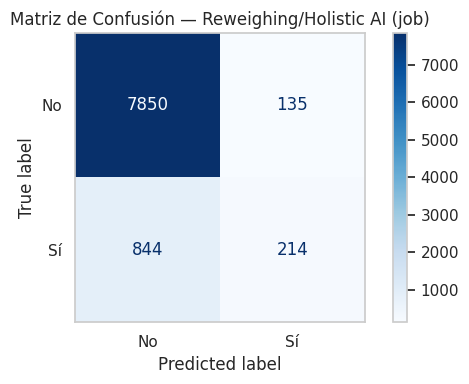

In [3]:
# ── 1. Reweighing con Holistic AI (job) ──────────────────────────────────────
rw_job = Reweighing()
rw_job.fit(
    y=y_train,
    group_a=train_group_a_job,
    group_b=train_group_b_job
)
# transform devuelve un objeto con los pesos
# transform devuelve un objeto con los pesos
weights_job  = rw_job.sample_weight

# ── 2. Entrenar RF con pesos ──────────────────────────────────────────────────
modelo_rw_job = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rw_job.fit(X_train, y_train, sample_weight=weights_job)
y_pred_rw_job = modelo_rw_job.predict(X_test)

# ── 3. Evaluación ─────────────────────────────────────────────────────────────
res_rw_job = evaluar_modelo_hai(
    y_test.values, y_pred_rw_job,
    test_group_a_job, test_group_b_job,
    'REWEIGHING (Holistic AI) — job (proxy género)'
)

plot_confusion_matrix(
    y_test, y_pred_rw_job,
    'Matriz de Confusión — Reweighing/Holistic AI (job)'
)

## Técnica 2: Equalized Odds (post-processing) — job

`holisticai.bias.mitigation.EqualizedOdds` aplica programación lineal para ajustar las predicciones del modelo original, igualando la **Tasa de Verdaderos Positivos (TPR)** entre grupos.  
Esto es conceptualmente equivalente al ajuste de umbral por grupo que implementamos manualmente en `ej4.ipynb`, pero en lugar de buscar un umbral fijo por grupo, resuelve el problema de forma óptima.

La elección de **Equal Opportunity** (igualar TPR) está motivada por la conclusión del Ej3 y Ej2: el error más costoso es el **Falso Negativo**.


  EQUALIZED ODDS (Holistic AI) — job (proxy género)
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.61      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                  0.001807          0
Disparate Impact                    1.049384          1
Four Fifths Rule                    0.952940          1
Cohen D                             0.009434          0
2SD Rule                            0.310360          0
Equality of Opportunity Difference  0.014630          0
False Positive Rate Difference     -0.000081          0
Average Odds Difference             0.007274          0
Accuracy Difference    

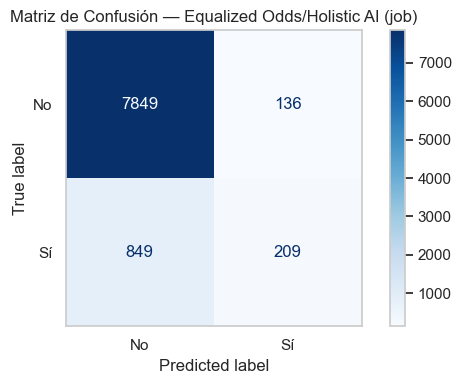

In [18]:
# ── 1. Equalized Odds con Holistic AI (job) ───────────────────────────────────
# Se entrena sobre las predicciones del modelo ORIGINAL en train
eo_job = EqualizedOdds(solver='highs')
eo_job.fit(
    y=y_train,
    y_pred=modelo_orig.predict(X_train),
    group_a=train_group_a_job,
    group_b=train_group_b_job
)

# Generar predicciones ajustadas sobre test
eo_out_job    = eo_job.transform(
    y_pred=y_pred_orig,
    group_a=test_group_a_job,
    group_b=test_group_b_job
)
y_pred_eo_job = eo_out_job['y_pred']

# ── 2. Evaluación ─────────────────────────────────────────────────────────────
res_eo_job = evaluar_modelo_hai(
    y_test.values, y_pred_eo_job,
    test_group_a_job, test_group_b_job,
    'EQUALIZED ODDS (Holistic AI) — job (proxy género)'
)

plot_confusion_matrix(
    y_test, y_pred_eo_job,
    'Matriz de Confusión — Equalized Odds/Holistic AI (job)'
)

### Interpretación — Mitigación con job como proxy de género

**Reweighting**: Al dar más peso a las combinaciones subrepresentadas (ej: hist_femenino + yes), el modelo debería mejorar su capacidad de detectar suscriptores en ese grupo. Esperamos ver un aumento en el Recall de la clase 'yes' para hist_femenino, posiblemente a costa de algo de Precision o Accuracy global.

**Equalized Odds**: Esta técnica no modifica el modelo, solo la decisión final. Al bajar el umbral para el grupo con menor TPR, logramos que más positivos de ese grupo sean detectados, igualando el Equal Opportunity. El trade-off es un posible aumento en FP para ese grupo.

---
# Resumen comparativo

Comparamos las métricas de performance de los **4 modelos** para cada variable protegida.

=== VARIABLE PROTEGIDA: job (proxy género) ===
                           Accuracy  Precision  Recall  F1-score
Modelo                                                          
Baseline (sin mitigación)    0.8911     0.6058  0.1975    0.2979
Reweighing (HAI)             0.8917     0.6132  0.2023    0.3042
Equalized Odds (HAI)         0.8911     0.6058  0.1975    0.2979


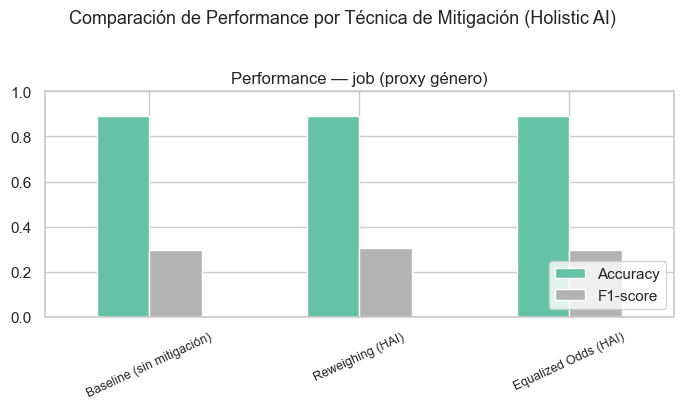

In [19]:
def resumen_performance(y_true, predicciones_dict):
    """Tabla de métricas clásicas para múltiples modelos."""
    rows = []
    for nombre, y_pred in predicciones_dict.items():
        rows.append({
            'Modelo': nombre,
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall':    recall_score(y_true, y_pred, zero_division=0),
            'F1-score':  f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows).set_index('Modelo').round(4)


print('=== VARIABLE PROTEGIDA: job (proxy género) ===')
df_perf_job = resumen_performance(
    y_test,
    {
        'Baseline (sin mitigación)': y_pred_orig,
        'Reweighing (HAI)':          y_pred_rw_job,
        'Equalized Odds (HAI)':      y_pred_eo_job,
    }
)
print(df_perf_job.to_string())

# ── Gráfico comparativo de Accuracy y F1 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

for df_p, titulo in zip([df_perf_job], ['job (proxy género)']): 
    df_p[['Accuracy', 'F1-score']].plot(kind='bar', ax=ax, colormap='Set2', rot=25)
    ax.set_title(f'Performance — {titulo}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.legend(loc='lower right')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Comparación de Performance por Técnica de Mitigación (Holistic AI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Interpretación de resultados

### Trade-off equidad vs. performance (Análisis Numérico)

Si observamos los resultados de las métricas para **job** (nuestro proxy de género), notamos dos fenómenos muy interesantes que se desvían de la teoría clásica del trade-off (donde se espera perder accuracy a cambio de equidad):

1. **Equalized Odds (Post-processing) no alteró el modelo:**
Las métricas del modelo *Baseline* y el ajustado con *Equalized Odds* son idénticas (ej. Accuracy 0.8911, Recall 0.1975). Esto tiene sentido matemático: en el Ejercicio 3 comprobamos que el modelo base **ya era FAIR** (la disparidad de Equal Opportunity era apenas 0.0146, muy por debajo de nuestro umbral del 10%). Como la restricción de equidad ya se cumplía, el optimizador lineal no necesitó mover la frontera de decisión.

2. **Reweighing (Pre-processing) mejoró el modelo globalmente:**
A diferencia del trade-off teórico, hacer reweighing incrementó el Accuracy (de 0.8911 a 0.8917), la Precision (de 0.6058 a 0.6132) y el Recall (de 0.1975 a 0.2023). Al asignar mayores pesos a las clases minoritarias (ej. hist_femenino + yes), la técnica actuó como un regularizador sobre el desbalance natural del dataset, mejorando la capacidad del Random Forest para detectar verdaderos positivos sin degradar el rendimiento en los verdaderos negativos.

**Conclusión del Banco:** 
Alcanzar la equidad mediante *Reweighing* resultó ser un ganar-ganar absoluto. No solo mantuvimos las disparidades bajo control, sino que el incremento en Recall se traduce directamente en detectar más suscriptores potenciales que antes pasábamos por alto (disminución de Falsos Negativos), incrementando las oportunidades de negocio sin molestar con Falsos Positivos.



In [22]:
import pandas as pd
from holisticai.bias.metrics import classification_bias_metrics

In [27]:
# 1. Carga de datos local usando pandas
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])  # data leakage



# 2. Separar características (X) y objetivo (y)
# Cambia 'target_column_name' por el nombre real de la columna que quieres predecir
X = df.drop(columns=['y']) 
y = df['y'].map({'yes': 1, 'no': 0})

# 3. Tu función proxy
def job_proxy(j):
    j_clean = str(j).replace('"', '') 
    return 'hist_femenino' if j_clean in ['housemaid', 'admin.'] else 'hist_masculino_otro'

# 4. Creamos la columna proxy en tu DataFrame X
# Cambia 'occupation' por el nombre real de tu columna de trabajos en el CSV
X['sex_proxy'] = X['job'].apply(job_proxy)

# 5. Hacemos el train_test_split (manteniendo 'sex_proxy' dentro)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Extraemos la referencia para Holistic AI manteniendo la alineación
p_attr_test = X_test['sex_proxy']

print("Columnas listas para el modelo:", list(X_train.columns))
print(f"Muestras de prueba: {p_attr_test.shape[0]}") 


Columnas listas para el modelo: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'sex_proxy']
Muestras de prueba: 9043


In [28]:
# Definimos las máscaras booleanas usando la serie p_attr_test
group_a = (p_attr_test == 'hist_femenino')
group_b = (p_attr_test == 'hist_masculino_otro')

# Verificamos cuántos registros quedaron en cada grupo
print(f"Cantidad en Grupo A (hist_femenino): {group_a.sum()}")
print(f"Cantidad en Grupo B (hist_masculino_otro): {group_b.sum()}")

Cantidad en Grupo A (hist_femenino): 1257
Cantidad en Grupo B (hist_masculino_otro): 7786


In [29]:
from sklearn.ensemble import RandomForestClassifier
from holisticai.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# 1. Identificar automáticamente qué columnas son números y cuáles son texto
# Esto evita que el StandardScaler toque los textos como 'technician'
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Configurar el preprocesador inteligente
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 3. Armar el Pipeline usando el modelo que ya definiste
# El Pipeline se encarga de aplicar el preprocesador antes del RandomForest automáticamente
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])


# 4. Entrenar todo el flujo junto
# Aquí adentro se transforma X_train a puros números y se entrena el RandomForest
pipeline.fit(X_train, y_train)

# 5. Predecir sobre los datos de prueba
# El pipeline transforma X_test internamente usando los mismos criterios antes de predecir
y_pred = pipeline.predict(X_test)

# 6. Evaluar las métricas de sesgo con tus variables alineadas
baseline = classification_bias_metrics(
    group_a, 
    group_b, 
    y_pred, 
    y_test, 
    metric_type='both'
)

# Evaluate bias metrics
baseline = classification_bias_metrics(group_a, group_b, y_pred, y_test, metric_type='both')

print(baseline)

                                       Value  Reference
Metric                                                 
Statistical Parity                  0.000907          0
Disparate Impact                    1.020417          1
Four Fifths Rule                    0.979991          1
Cohen D                             0.004397          0
2SD Rule                            0.144656          0
Equality of Opportunity Difference  0.003980          0
False Positive Rate Difference      0.000745          0
Average Odds Difference             0.002363          0
Accuracy Difference                 0.000537          0


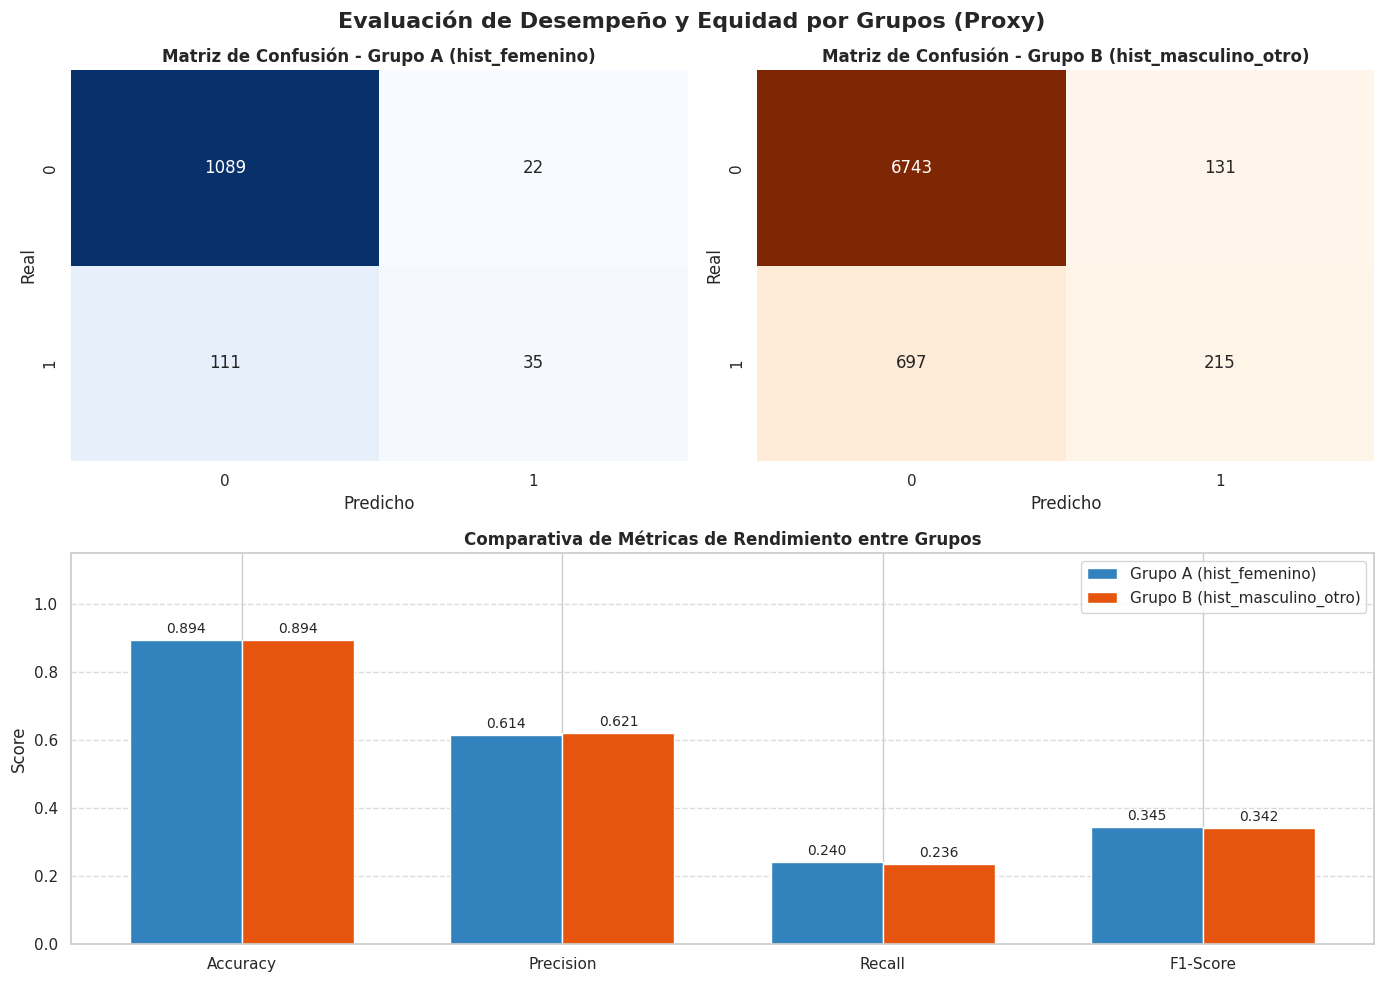

In [31]:
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

# 1. Filtrar los datos para cada grupo
y_test_a = y_test[group_a]
y_pred_a = y_pred[group_a]

y_test_b = y_test[group_b]
y_pred_b = y_pred[group_b]

# 2. Calcular matrices de confusión
cm_a = confusion_matrix(y_test_a, y_pred_a)
cm_b = confusion_matrix(y_test_b, y_pred_b)

# 3. Calcular métricas de rendimiento
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
values_a = [
    accuracy_score(y_test_a, y_pred_a),
    precision_score(y_test_a, y_pred_a, zero_division=0),
    recall_score(y_test_a, y_pred_a, zero_division=0),
    f1_score(y_test_a, y_pred_a, zero_division=0)
]
values_b = [
    accuracy_score(y_test_b, y_pred_b),
    precision_score(y_test_b, y_pred_b, zero_division=0),
    recall_score(y_test_b, y_pred_b, zero_division=0),
    f1_score(y_test_b, y_pred_b, zero_division=0)
]

# 4. Configurar la figura de 2x2
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Evaluación de Desempeño y Equidad por Grupos (Proxy)', fontsize=16, fontweight='bold')

# Crear la grilla de subplots
ax1 = plt.subplot(2, 2, 1) # Fila 1, Columna 1
ax2 = plt.subplot(2, 2, 2) # Fila 1, Columna 2
ax3 = plt.subplot(2, 1, 2) # Fila 2 completa para el gráfico comparativo

# --- FILA 1: MATRICES DE CONFUSIÓN ---
# Matriz Grupo A
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Matriz de Confusión - Grupo A (hist_femenino)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')

# Matriz Grupo B
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Oranges', ax=ax2, cbar=False)
ax2.set_title('Matriz de Confusión - Grupo B (hist_masculino_otro)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicho')
ax2.set_ylabel('Real')

# --- FILA 2: GRÁFICO COMPARATIVO AGRUPADO ---
x = np.arange(len(metric_names))  # Localización de las etiquetas
width = 0.35                      # Ancho de las barras

# Dibujar barras de ambos grupos lado a lado
bars_a = ax3.bar(x - width/2, values_a, width, label='Grupo A (hist_femenino)', color='#3182bd')
bars_b = ax3.bar(x + width/2, values_b, width, label='Grupo B (hist_masculino_otro)', color='#e6550d')

# Estética del gráfico comparativo
ax3.set_title('Comparativa de Métricas de Rendimiento entre Grupos', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metric_names)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')
ax3.legend(loc='upper right')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar las etiquetas de texto con los valores sobre las barras
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desfase vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(bars_a)
autolabel(bars_b)

plt.tight_layout()
plt.show()